In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:\\Users\\Admin\\Desktop\\retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# Data Exploration

In [3]:
df.shape

(1000, 9)

In [4]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


# Data Cleaning

## Null values

In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

# Duplicate values

In [8]:
print(df.duplicated().sum())

0


# Data Analysis

In [22]:
a=df.groupby("Product Category")["Quantity"].max()
a=pd.DataFrame(a)

### Beauty, clothing and Electronics are the maximum selling products

In [28]:
b=df.groupby("Gender")["Total Amount"].mean()
b=pd.DataFrame(b)

### female are generating more revenue for the shop

In [32]:
c=pd.DataFrame(df.groupby("Product Category")["Age"].mean())

### The target customers are around 40 years of age

In [12]:
a=df["Total Amount"].sum()

In [13]:
b=df["Customer ID"].count()

In [14]:
a/b

np.float64(456.0)

In [36]:
d=pd.DataFrame(df.groupby("Product Category")["Total Amount"].mean().sort_values(ascending=False))

### Beauty is generating the highest revenue

In [44]:
e=pd.DataFrame(df.groupby("Product Category")["Price per Unit"].count().sort_values(ascending=False))

### Clothing is the maximum selling product

In [48]:
f=df.groupby("Product Category")["Price per Unit"].sum().sort_values(ascending=False)
f

Product Category
Electronics    62210
Clothing       61175
Beauty         56505
Name: Price per Unit, dtype: int64

# Data Visualisation

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

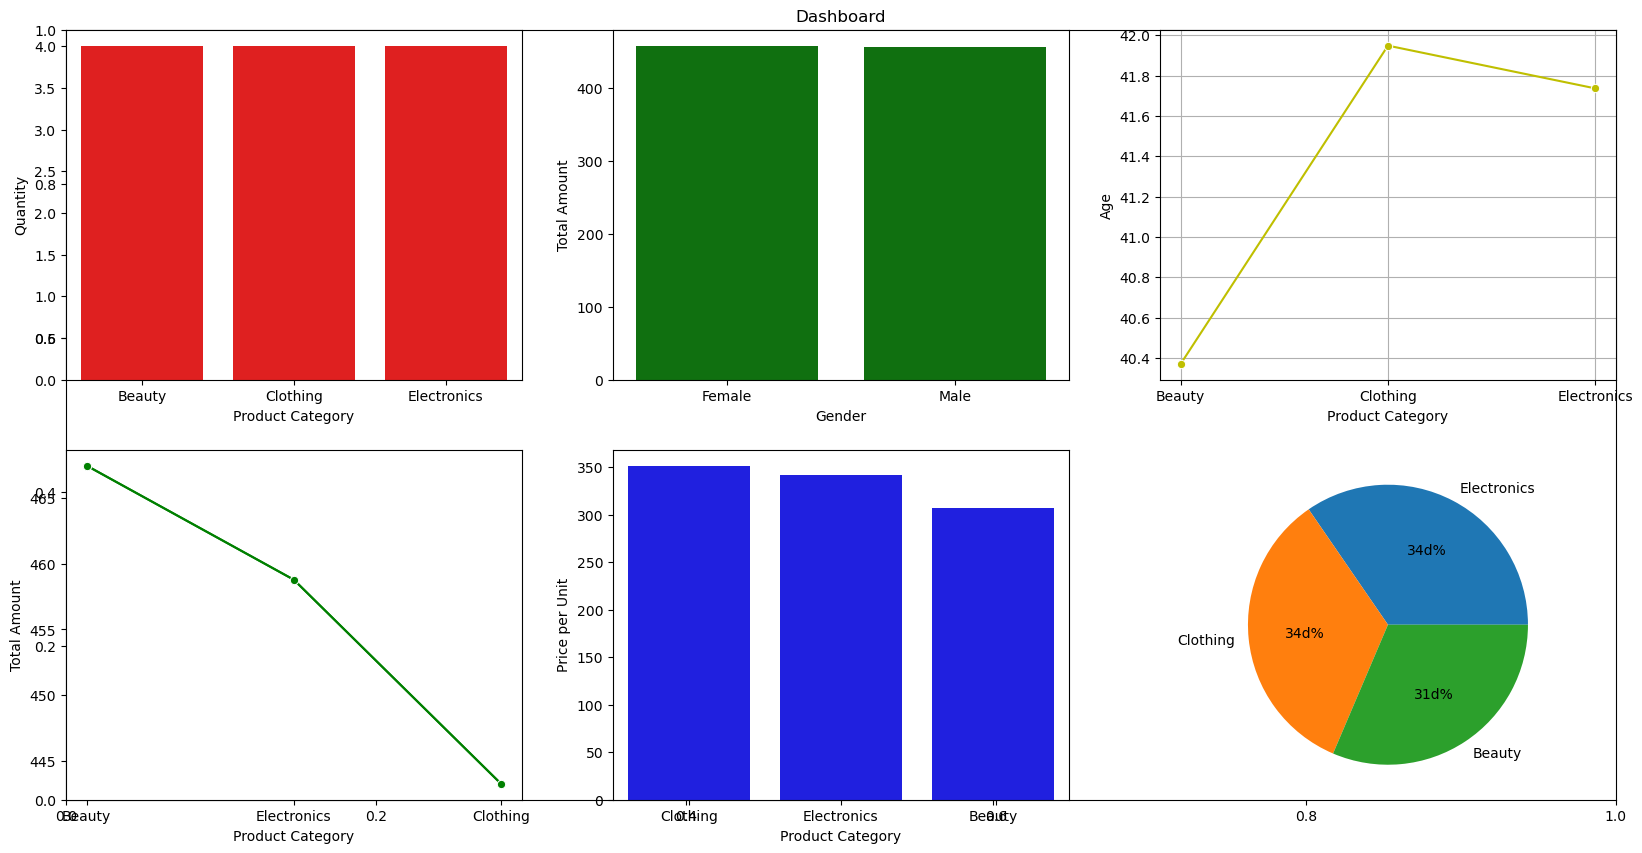

In [53]:

plt.figure(figsize=(20,10))
plt.title("Dashboard")
plt.subplot(2,3,1)
sns.barplot(x="Product Category",y="Quantity",color="red",data=a)
plt.subplot(2,3,2)
sns.barplot(x="Gender",y="Total Amount",color="green",data=b)
plt.subplot(2,3,3)
sns.lineplot(x="Product Category",y="Age",color="y",marker="o",data=c)
plt.grid(True)
plt.subplot(2,3,4)
sns.lineplot(x="Product Category",y="Total Amount",color="green",marker="o",data=d)
plt.subplot(2,3,4)
sns.lineplot(x="Product Category",y="Total Amount",color="green",marker="o",data=d)
plt.subplot(2,3,5)
sns.barplot(x="Product Category",y="Price per Unit",color="blue",data=e)
plt.subplot(2,3,6)
plt.pie(f.values,labels=f.index,autopct="%id%%")
plt.show()

# Data Story Telling

### Beauty, electronics and Clothing are the maximum selling product
### Average Revenue is around 450 $
### Target Customers is around 40 years of age
### Beauty product is generating highest revenue
### Clothing is the maximum selling product
### Electronics product has maximum total price